In [34]:
import os
import pickle
from pathlib import Path
import polars as pl
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from typing import Dict
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings("ignore")
#os.chdir("AWS_theDiceGame")


# ==============================================================================
# SECCIÓN 1: CARGA Y CONFIGURACIÓN DEL ENTORNO
# ==============================================================================

In [35]:
class CloudscapeDataset:
    def __init__(self, df_architectures, df_nodes, df_edges, graphs):
        self.architectures = df_architectures
        self.nodes = df_nodes
        self.edges = df_edges
        self.graphs = graphs

In [36]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.5
})

In [37]:
BASE_DIR = Path(".")
INPUT_DIR = BASE_DIR / "output_analytics"
BUNDLE_PATH = INPUT_DIR / "cloudscape_pipeline_bundle.pkl"
DATA_DIR = BASE_DIR / "data"
GRAPHS_DIR = DATA_DIR / "graphs"
SERVICES_CSV = DATA_DIR / "services.csv"


if not BUNDLE_PATH.exists():
    raise FileNotFoundError(f" No se encontró el bundle en {BUNDLE_PATH}. Ejecuta el Preprocesamiento primero.")

with open(BUNDLE_PATH, "rb") as f:
    bundle = pickle.load(f)

df_services_master: pl.DataFrame = bundle["df_services_master"]
df_cooccurrences: pl.DataFrame = bundle["df_cooccurrences"]
df_transitions: pl.DataFrame = bundle["df_transitions"]
G_cooc_master: nx.Graph = bundle["G_cooc_master"]

print(f"   • Servicios: {df_services_master.height}")
print(f"   • Nodos: {G_cooc_master.number_of_nodes()}")

   • Servicios: 160
   • Nodos: 78


# ==============================================================================
# SECCIÓN 2: ANÁLISIS DE DEPENDENCIAS, CARAS COMPUESTAS Y ASIGNACIÓN DE DADOS
# ==============================================================================

In [38]:
df_services_cat = pl.read_csv(SERVICES_CSV).select(['name', 'aws_product_categories'])
cat_map_raw = {}
for row in df_services_cat.iter_rows(named=True):
    cats = [c.strip() for c in row['aws_product_categories'].split(',')] if row['aws_product_categories'] else []
    cat_map_raw[row['name']] = cats

group_mapping = {
    'Compute': ['Compute'],
    'Storage': ['Storage'],
    'Networking': ['Networking and Content Delivery'],
    'Integration': ['Application Integration'],
    'Analytics': ['Analytics'],
    'Security': ['Security Identity and Compliance'],
    'Management': ['Management and Governance'],
    'IoT': ['IoT'],
    'Media': ['Media Services'],
    'Developer': ['Developer Tools'],
    'Database': ['Database'],
    'ML': ['ML'],
    'Other': []
}

In [39]:
def get_service_category(service):
    cats = cat_map_raw.get(service, [])
    for group, keywords in group_mapping.items():
        for kw in keywords:
            if any(kw in c for c in cats):
                return group
    cap = df_services_master.filter(pl.col('service') == service)['capability'].first()
    if cap == 'compute':
        return 'Compute'
    elif cap == 'storage':
        return 'Storage'
    elif cap == 'networking':
        return 'Networking'
    elif cap == 'integration':
        return 'Integration'
    else:
        return 'Other'

def son_incompatibles(s1: str, s2: str, G: nx.Graph) -> bool:
    if s1 == s2: return False
    if not G.has_node(s1) or not G.has_node(s2): return True
    return not G.has_edge(s1, s2)

def buscar_conflicto_con_dados(servicio: str, dados_creados: list, G: nx.Graph):
    for d in dados_creados:
        for obj in d['objetos']:
            if son_incompatibles(servicio, obj['service'], G):
                return (d['id'], obj['service'])
    return None

def buscar_conflicto_interno(servicio: str, dado_actual: list, G: nx.Graph):
    for obj in dado_actual:
        if son_incompatibles(servicio, obj['service'], G):
            return obj['service']
    return None

def calcular_tasa_incompatibilidad(servicio: str, grupo_poblacion: list, G: nx.Graph) -> float:
    if not grupo_poblacion: return 0.0
    choques = sum(1 for o in grupo_poblacion if son_incompatibles(servicio, o, G))
    return choques / len(grupo_poblacion)

In [40]:
def crear_dados_heuristticos(
        df_services_master: pl.DataFrame,
        G_cooc_master: nx.Graph,
        umbral_min_archs: int = 15,
        max_incomp_compute_storage: float = 0.40,
        max_incomp_compute_resto: float = 0.50,
        max_incomp_storage_resto: float = 0.50
):
    df_aws = df_services_master.filter(
        (pl.col('is_aws') == True) &
        (pl.col('num_architectures') >= umbral_min_archs)
    ).sort('num_architectures', descending=True)

    servicios_base = df_aws['service'].to_list()
    weights_base = {row['service']: row['base_prob_weight'] for row in df_aws.iter_rows(named=True)}
    archs_base = {row['service']: row['num_architectures'] for row in df_aws.iter_rows(named=True)}
    cats_base = {s: get_service_category(s) for s in servicios_base}

    def crear_obj(s):
        return {
            'service': s, 'display': s, 'category': cats_base[s],
            'is_compound': False, 'bases': [],
            'weight': weights_base.get(s, 0.0), 'archs': archs_base.get(s, 0)
        }

    dados_creados = []
    descartados_totales = []

    print("\n[PASO 1] Evaluando y Construyendo Dado de Cómputo...")
    stack_compute = [s for s in servicios_base if cats_base[s] == 'Compute']
    stack_storage = [s for s in servicios_base if cats_base[s] == 'Storage']
    otros_servicios = [s for s in servicios_base if cats_base[s] not in ('Compute', 'Storage')]

    compute_sociables = []
    compute_rechazados_por_toxicos = []

    print("    Comprobación de candidatos de Cómputo:")
    for c in stack_compute:
        tasa_st = calcular_tasa_incompatibilidad(c, stack_storage, G_cooc_master)
        tasa_resto = calcular_tasa_incompatibilidad(c, otros_servicios, G_cooc_master)

        pasa_st = tasa_st <= max_incomp_compute_storage
        pasa_resto = tasa_resto <= max_incomp_compute_resto

        if pasa_st and pasa_resto:
            print(f"        '{c}': APROBADO (Incomp. Storage: {tasa_st:.0%}, Incomp. Resto: {tasa_resto:.0%})")
            compute_sociables.append(c)
        else:
            motivo = []
            if not pasa_st: motivo.append(f"Storage {tasa_st:.0%} > {max_incomp_compute_storage:.0%}")
            if not pasa_resto: motivo.append(f"Resto {tasa_resto:.0%} > {max_incomp_compute_resto:.0%}")
            print(f"        '{c}': RECHAZADO por tóxico [{', '.join(motivo)}]. Pasa al stack general.")
            compute_rechazados_por_toxicos.append(c)

    candidatos_compute = compute_sociables if compute_sociables else stack_compute

    prioridad_compute = []
    for c in candidatos_compute:
        inc_ext = sum(1 for o in (stack_storage + otros_servicios) if son_incompatibles(c, o, G_cooc_master))
        inc_int = sum(1 for c2 in candidatos_compute if c != c2 and son_incompatibles(c, c2, G_cooc_master))
        prioridad_compute.append((inc_ext, -inc_int, -archs_base[c], c))

    prioridad_compute.sort()
    stack_compute_ordenado = [item[3] for item in prioridad_compute]

    seleccion_compute = stack_compute_ordenado[:4]
    restantes_compute = stack_compute_ordenado[4:] + compute_rechazados_por_toxicos

    print(f"   >>> Seleccionados top 4 para Cómputo: {seleccion_compute}")
    dados_creados.append({'id': 'Dado_Compute', 'objetos': [crear_obj(s) for s in seleccion_compute]})

    computo_devuelto = []
    for s in restantes_compute:
        conflicto = next((sel for sel in seleccion_compute if son_incompatibles(s, sel, G_cooc_master)), None)
        if conflicto:
            print(f"DESCARTADO '{s}' del resto de Cómputo: Incompatible con miembro base '{conflicto}'.")
            descartados_totales.append(s)
        else:
            computo_devuelto.append(s)

    print("\n[PASO 2] Evaluando y Construyendo Dado de Storage...")
    stack_storage_limpio = []
    for s in stack_storage:
        conflicto = buscar_conflicto_con_dados(s, dados_creados, G_cooc_master)
        if not conflicto:
            stack_storage_limpio.append(s)
        else:
            print(
                f"DESCARTADO '{s}' de Storage antes de evaluar: Incompatible con '{conflicto[1]}' ({conflicto[0]}).")
            descartados_totales.append(s)

    servicios_no_storage = [s for s in servicios_base if cats_base[s] != 'Storage' and s not in descartados_totales]
    storage_sociables = []
    storage_rechazados = []

    print("    Comprobación de candidatos de Storage:")
    for st in stack_storage_limpio:
        tasa_resto = calcular_tasa_incompatibilidad(st, servicios_no_storage, G_cooc_master)
        if tasa_resto <= max_incomp_storage_resto:
            print(f"'{st}': APROBADO (Incomp. Resto: {tasa_resto:.0%})")
            storage_sociables.append(st)
        else:
            print(
                f"'{st}': RECHAZADO por tóxico [Resto {tasa_resto:.0%} > {max_incomp_storage_resto:.0%}]. Pasa al stack general.")
            storage_rechazados.append(st)

    candidatos_storage = storage_sociables if storage_sociables else stack_storage_limpio

    prioridad_storage = []
    for st in candidatos_storage:
        inc_ext = sum(1 for o in servicios_no_storage if son_incompatibles(st, o, G_cooc_master))
        inc_int = sum(1 for st2 in candidatos_storage if st != st2 and son_incompatibles(st, st2, G_cooc_master))
        prioridad_storage.append((inc_ext, -inc_int, -archs_base[st], st))

    prioridad_storage.sort()
    stack_storage_ordenado = [item[3] for item in prioridad_storage]

    seleccion_storage = stack_storage_ordenado[:4]
    restantes_storage = stack_storage_ordenado[4:] + storage_rechazados

    print(f"   >>> Seleccionados top 4 para Storage: {seleccion_storage}")
    dados_creados.append({'id': 'Dado_Storage', 'objetos': [crear_obj(s) for s in seleccion_storage]})

    storage_devuelto = []
    for s in restantes_storage:
        conflicto = next((sel for sel in seleccion_storage if son_incompatibles(s, sel, G_cooc_master)), None)
        if conflicto:
            print(f"DESCARTADO '{s}' del resto de Storage: Incompatible con miembro base '{conflicto}'.")
            descartados_totales.append(s)
        else:
            storage_devuelto.append(s)

    asignados_o_descartados = set(seleccion_compute + seleccion_storage + descartados_totales)
    stack_general = [s for s in servicios_base if s not in asignados_o_descartados]
    stack_general = list(set(stack_general + computo_devuelto + storage_devuelto))

    stack_general_valido = []
    for s in stack_general:
        conflicto = buscar_conflicto_con_dados(s, dados_creados, G_cooc_master)
        if not conflicto:
            stack_general_valido.append(s)
        else:
            print(f"DESCARTADO '{s}' (Reconstrucción): Incompatible con '{conflicto[1]}' (de {conflicto[0]}).")
            descartados_totales.append(s)
    stack_general = stack_general_valido

    def reordenar_stack(stack):
        conteo_cats = Counter(cats_base[s] for s in stack)
        return sorted(stack, key=lambda s: (-conteo_cats[cats_base[s]], cats_base[s], -archs_base[s]))

    stack_general = reordenar_stack(stack_general)

    print("\n[PASO 4] Construcción Iterativa (Agrupando incompatibles dentro de las caras)...")
    dado_counter = 1

    while stack_general:
        base = stack_general.pop(0)
        conflicto = buscar_conflicto_con_dados(base, dados_creados, G_cooc_master)
        if conflicto:
            print(f"DESCARTADO cabecera '{base}': Choca externamente con '{conflicto[1]}' ({conflicto[0]}).")
            descartados_totales.append(base)
            continue

        cat_dado = cats_base[base]
        id_nombre = f"Dado_{cat_dado}" if not any(
            d['id'] == f"Dado_{cat_dado}" for d in dados_creados) else f"Dado_{cat_dado}_{dado_counter}"
        if id_nombre.startswith(f"Dado_{cat_dado}_"): dado_counter += 1

        print(f"\nCreando nuevo dado: [{id_nombre}] | Cabecera: '{base}'")
        dado_actual = [crear_obj(base)]

        hubo_adicion = True
        while len(dado_actual) < 6 and hubo_adicion:
            hubo_adicion = False
            i = 0
            while i < len(stack_general) and len(dado_actual) < 6:
                cand = stack_general[i]
                conflicto_ext = buscar_conflicto_con_dados(cand, dados_creados, G_cooc_master)
                if conflicto_ext:
                    print(
                        f"DESCARTADO '{cand}': Choca externamente con '{conflicto_ext[1]}' ({conflicto_ext[0]}).")
                    descartados_totales.append(stack_general.pop(i))
                    continue

                conflicto_int = buscar_conflicto_interno(cand, dado_actual, G_cooc_master)
                if conflicto_int:
                    print(
                        f"ENCAPSULADO POR INCOMPATIBILIDAD '{cand}' (Choca internamente con '{conflicto_int}')")
                    dado_actual.append(crear_obj(stack_general.pop(i)))
                    hubo_adicion = True
                else:
                    i += 1

        i = 0
        while i < len(stack_general) and len(dado_actual) < 6:
            cand = stack_general[i]
            conflicto_ext = buscar_conflicto_con_dados(cand, dados_creados, G_cooc_master)
            if conflicto_ext:
                print(f"DESCARTADO '{cand}': Choca externamente con '{conflicto_ext[1]}' ({conflicto_ext[0]}).")
                descartados_totales.append(stack_general.pop(i))
                continue
            print(f"      ➕ AGARRADO RELLENO COMPATIBLE '{cand}'")
            dado_actual.append(crear_obj(stack_general.pop(i)))

        dados_creados.append({'id': id_nombre, 'objetos': dado_actual})
        stack_general = reordenar_stack(stack_general)

    if len(dados_creados) > 2 and len(dados_creados[-1]['objetos']) == 1:
        print("\n[PASO 6] Fusión de Dado Unitario residual...")
        ultimo_obj = dados_creados[-1]['objetos'][0]
        dado_eliminado = dados_creados.pop()
        dados_creados[-1]['objetos'].append(ultimo_obj)
        print(
            f"Se elimina '{dado_eliminado['id']}' y se añade '{ultimo_obj['service']}' a '{dados_creados[-1]['id']}'.")

    print("\n" + "=" * 70)
    print(
        f" RESULTADO: {len(dados_creados)} dados creados | {len(descartados_totales)} servicios descartados en total.")
    print("=" * 70)

    output_rows = []
    for d in dados_creados:
        for obj in d['objetos']:
            output_rows.append({
                'dado_id': d['id'], 'service': obj['service'],
                'display_face': obj['display'], 'is_compound': obj['is_compound'],
                'bases': ';'.join(obj['bases']) if obj['bases'] else '',
                'weight': obj['weight']
            })

    return pl.DataFrame(output_rows), dados_creados

In [41]:
df_asignacion, dados_finales = crear_dados_heuristticos(
    df_services_master,
    G_cooc_master,
    umbral_min_archs=20,
    max_incomp_compute_storage=0.40,
    max_incomp_compute_resto=0.30
)

print("\n" + "=" * 60)
print("     DETALLE FINAL DE DADOS Y SUS CARAS ASIGNADAS")
print("=" * 60)

for d in dados_finales:
    servicios_dado = [obj['service'] for obj in d['objetos']]
    cant_elementos = len(servicios_dado)
    print(f"\n{d['id']}  -->  [{cant_elementos} elementos]")
    for servicio in servicios_dado:
        print(f"   • {servicio}")

print("\n" + "=" * 60)
print(f"TOTAL DE DADOS CREADOS: {len(dados_finales)}")
print("=" * 60)


[PASO 1] Evaluando y Construyendo Dado de Cómputo...
    Comprobación de candidatos de Cómputo:
        'Lambda': APROBADO (Incomp. Storage: 0%, Incomp. Resto: 0%)
        'EC2': APROBADO (Incomp. Storage: 0%, Incomp. Resto: 0%)
        'EKS': APROBADO (Incomp. Storage: 0%, Incomp. Resto: 10%)
        'ECS': APROBADO (Incomp. Storage: 0%, Incomp. Resto: 20%)
        'Fargate': RECHAZADO por tóxico [Resto 45% > 30%]. Pasa al stack general.
   >>> Seleccionados top 4 para Cómputo: ['Lambda', 'EC2', 'EKS', 'ECS']
DESCARTADO 'Fargate' del resto de Cómputo: Incompatible con miembro base 'EKS'.

[PASO 2] Evaluando y Construyendo Dado de Storage...
    Comprobación de candidatos de Storage:
'S3': APROBADO (Incomp. Resto: 0%)
   >>> Seleccionados top 4 para Storage: ['S3']
DESCARTADO 'RedShift' (Reconstrucción): Incompatible con 'ECS' (de Dado_Compute).
DESCARTADO 'StepFunctions' (Reconstrucción): Incompatible con 'EKS' (de Dado_Compute).
DESCARTADO 'Glue' (Reconstrucción): Incompatible con '

# ==============================================================================
# SECCIÓN 3: DISCRETIZACIÓN A 100 CARAS Y OPTIMIZACIÓN A DADOS REALES
# ==============================================================================

In [42]:
def calcular_caras_por_dado(
        df_asignacion: pl.DataFrame,
        max_caras: int = 100
) -> pl.DataFrame:
    resultados = []
    for dado_id, df_dado in df_asignacion.group_by("dado_id"):
        dado_id = dado_id[0] if isinstance(dado_id, tuple) else dado_id
        pesos = df_dado["weight"].to_numpy()
        servicios = df_dado["service"].to_list()

        prob = pesos / pesos.sum()
        cuotas = prob * max_caras
        caras = np.floor(cuotas).astype(int)
        caras = np.maximum(caras, 1)

        diff = max_caras - caras.sum()
        restos = cuotas - caras
        while diff > 0:
            idx = np.argmax(restos)
            caras[idx] += 1
            restos[idx] = -1.0
            diff -= 1
        while diff < 0:
            idx = np.argmin(restos[caras > 1])
            if caras[idx] > 1:
                caras[idx] -= 1
                restos[idx] = 2.0
                diff += 1
            else:
                break

        for serv, p, c in zip(servicios, prob, caras):
            resultados.append({
                "dado_id": dado_id,
                "service": serv,
                "prob_continua": round(p, 4),
                "num_caras_100": int(c),
                "prob_fisica_100": round(c / max_caras, 4)
            })
    return pl.DataFrame(resultados)

def encontrar_dado_optimo(pesos_prob, formas_posibles=[1,2,4,6, 8, 10, 12, 20]):
    mejor_forma = 6
    min_error = float('inf')
    mejor_dist = None
    for N in formas_posibles:
        cuotas = pesos_prob * N
        caras = np.floor(cuotas).astype(int)
        while caras.sum() < N:
            idx = np.argmax(cuotas - caras)
            caras[idx] += 1
        error = np.sum(np.abs(cuotas - caras))
        if error < min_error:
            min_error = error
            mejor_forma = N
            mejor_dist = caras.copy()
    return mejor_forma, mejor_dist

In [43]:
df_100 = calcular_caras_por_dado(df_asignacion, max_caras=100)

resultados_opt = []
for dado_id, df_dado in df_asignacion.group_by("dado_id"):
    dado_id = dado_id[0] if isinstance(dado_id, tuple) else dado_id
    pesos = df_dado["weight"].to_numpy()
    pesos = pesos / pesos.sum()  # normalizar
    N_opt, dist = encontrar_dado_optimo(pesos)
    for serv, caras in zip(df_dado["service"].to_list(), dist):
        resultados_opt.append({
            "dado_id": dado_id,
            "forma_dado": f"d{N_opt}",
            "service": serv,
            "num_caras": int(caras)
        })

df_opt = pl.DataFrame(resultados_opt)
print("Optimización completada.")

print("\nResumen de dados optimizados:")
print(df_opt.group_by(["dado_id", "forma_dado"]).len().sort("dado_id"))

df_100.write_csv("distribucion_100_caras.csv")
df_opt.write_csv("diseño_final_dados_cloud.csv")
print("\nArchivos exportados: distribucion_100_caras.csv y diseño_final_dados_cloud.csv")

Optimización completada.

Resumen de dados optimizados:
shape: (4, 3)
┌──────────────────┬────────────┬─────┐
│ dado_id          ┆ forma_dado ┆ len │
│ ---              ┆ ---        ┆ --- │
│ str              ┆ str        ┆ u32 │
╞══════════════════╪════════════╪═════╡
│ Dado_Compute     ┆ d10        ┆ 4   │
│ Dado_Database    ┆ d10        ┆ 6   │
│ Dado_Integration ┆ d6         ┆ 2   │
│ Dado_Storage     ┆ d1         ┆ 1   │
└──────────────────┴────────────┴─────┘

Archivos exportados: distribucion_100_caras.csv y diseño_final_dados_cloud.csv


# ==============================================================================
# SECCIÓN 4: VISUALIZACIÓN DEL DISEÑO (COMPARATIVO A 100 CARAS)
# ==============================================================================

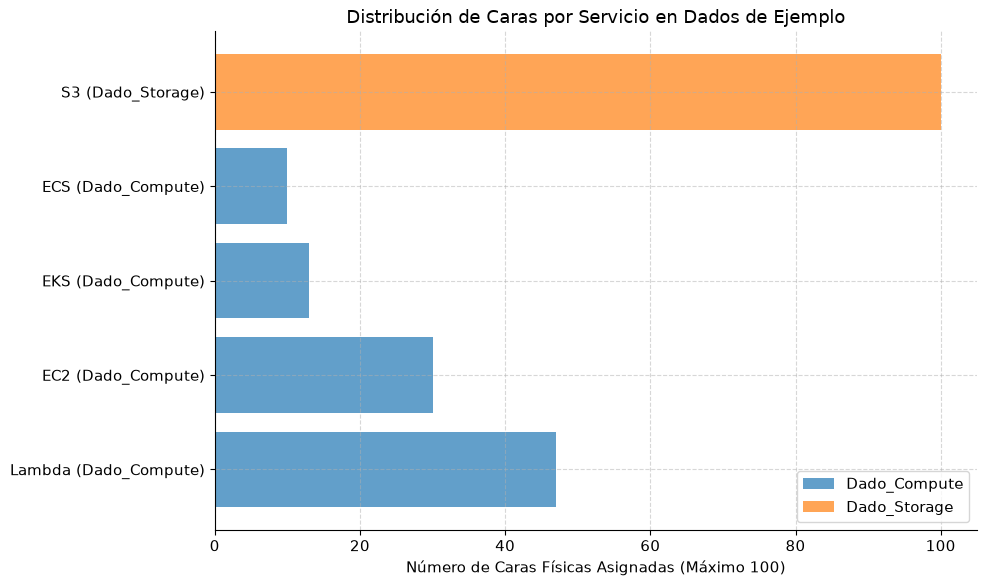

In [44]:
dados_ejemplo = ["Dado_Compute", "Dado_Storage"]
df_viz = df_100.filter(pl.col("dado_id").is_in(dados_ejemplo))

fig, ax = plt.subplots(figsize=(10, 6))
for dado_id, color in zip(dados_ejemplo, ["#1f77b4", "#ff7f0e"]):
    data = df_viz.filter(pl.col("dado_id") == dado_id)
    y_labels = [f"{s} ({dado_id})" for s in data["service"].to_list()]
    ax.barh(y_labels, data["num_caras_100"].to_list(), label=dado_id, color=color, alpha=0.7)

ax.set_xlabel("Número de Caras Físicas Asignadas (Máximo 100)")
ax.set_title("Distribución de Caras por Servicio en Dados de Ejemplo")
ax.legend()
plt.tight_layout()
plt.show()

# ==============================================================================
# SECCIÓN 5: VISUALIZACIÓN FINAL DEL SET DE DADOS CLOUD
# ==============================================================================

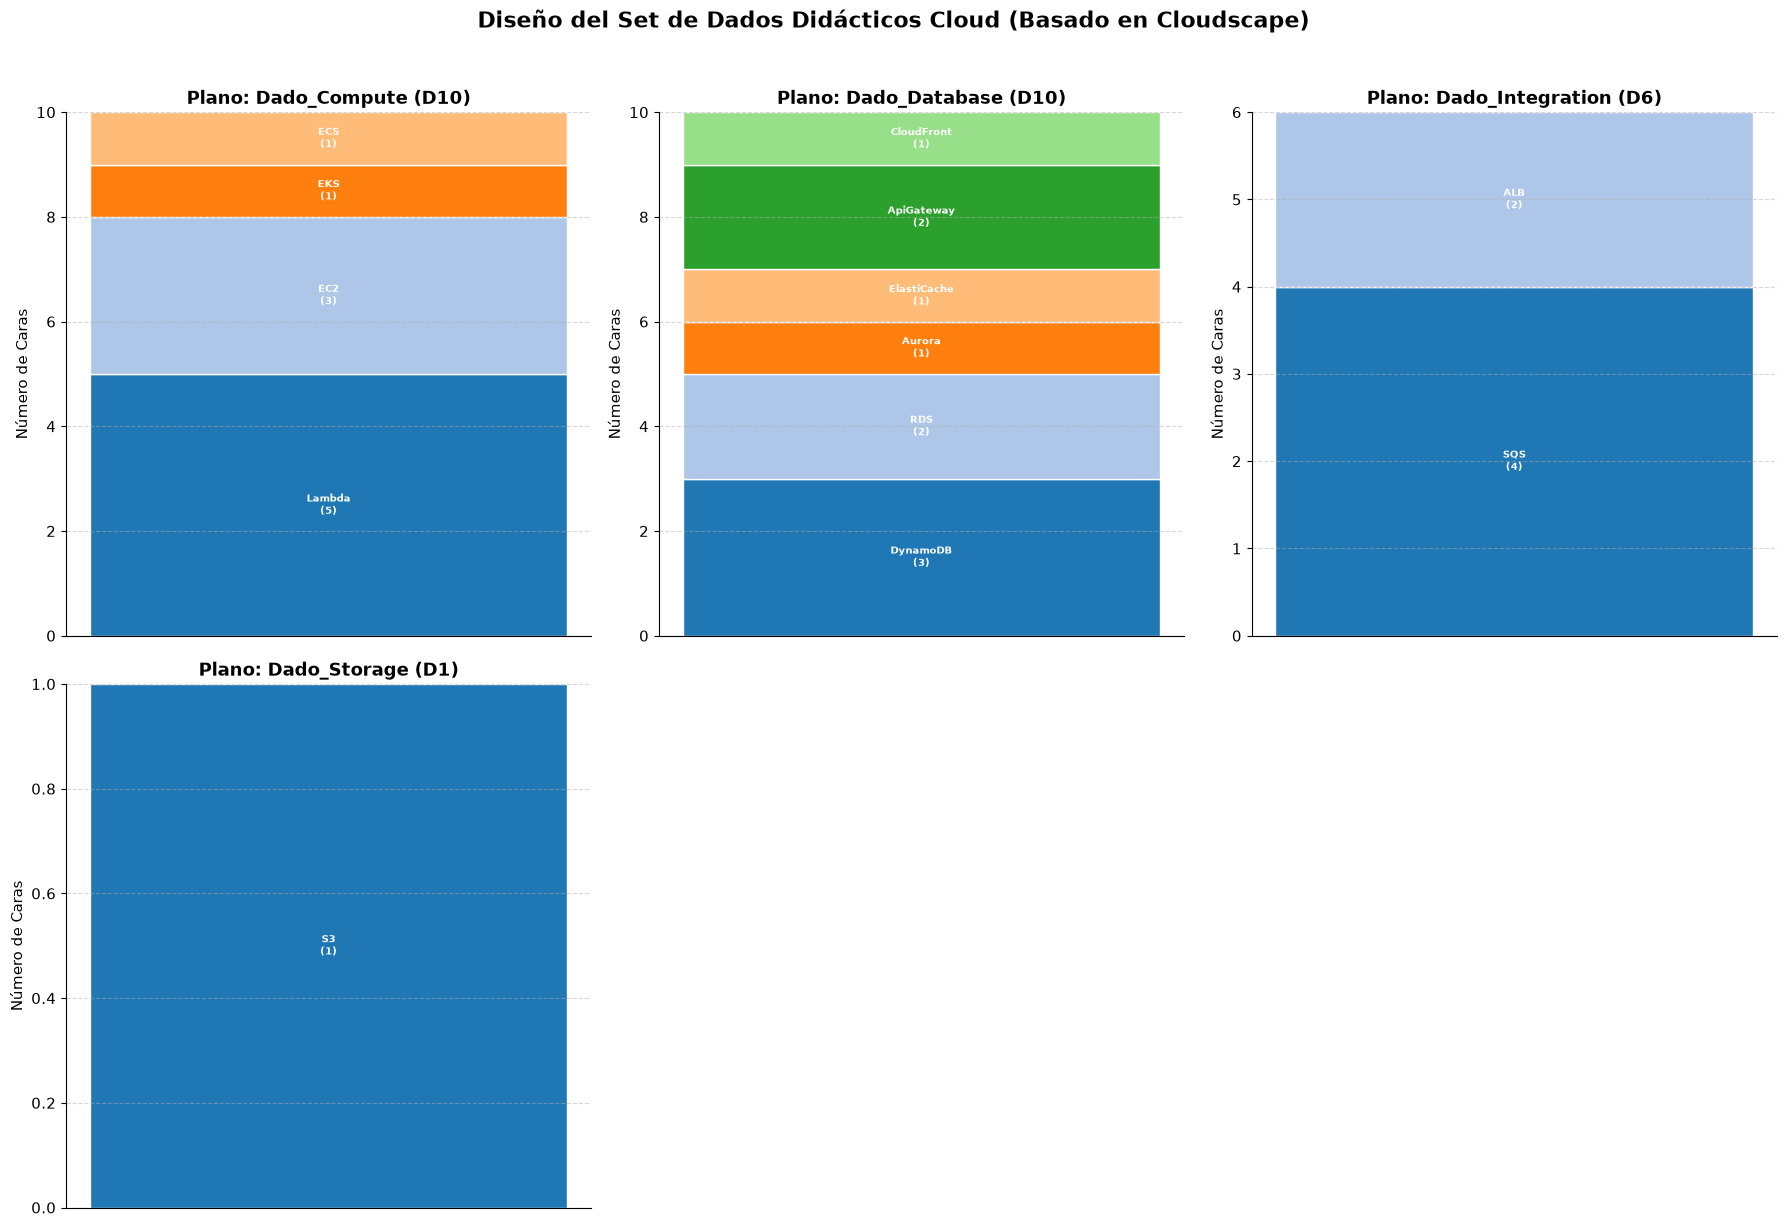

In [45]:
dados_resumen = df_opt.select(["dado_id", "forma_dado"]).unique().sort("dado_id")
dados_ids = dados_resumen["dado_id"].to_list()
formas = dados_resumen["forma_dado"].to_list()

n_dados = len(dados_ids)
n_cols = 3
n_rows = int(np.ceil(n_dados / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
axes = np.array(axes).reshape(-1)

cmap = plt.get_cmap("tab20")

for i, (dado_id, forma) in enumerate(zip(dados_ids, formas)):
    ax = axes[i]
    df_dado = df_opt.filter(pl.col("dado_id") == dado_id)

    n_caras_total = int(forma.replace("d", ""))
    servicios = df_dado["service"].to_list()
    caras = df_dado["num_caras"].to_list()

    bottom = 0
    for j, (serv, val) in enumerate(zip(servicios, caras)):
        ax.bar(0, val, bottom=bottom, color=cmap(j % 20), edgecolor="white", width=0.5)
        ax.text(0, bottom + val / 2, f"{serv}\n({val})", ha='center', va='center',
                fontsize=7, color='white', fontweight='bold')
        bottom += val

    ax.set_ylim(0, n_caras_total)
    ax.set_title(f"Plano: {dado_id} ({forma.upper()})", fontweight="bold")
    ax.set_xticks([])
    ax.set_ylabel("Número de Caras")

for k in range(n_dados, len(axes)):
    axes[k].axis("off")

plt.suptitle("Diseño del Set de Dados Didácticos Cloud (Basado en Cloudscape)",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ==============================================================================
# SECCIÓN 6: VISUALIZACIÓN FINAL DEL SET DE DADOS CLOUD
# ==============================================================================

In [46]:
def simular_lanzamiento(df_opt: pl.DataFrame) -> list[str]:
    seleccionados = []
    for dado_id, df_dado in df_opt.group_by("dado_id"):
        forma = df_dado["forma_dado"].first()
        total_caras = int(forma.replace("d", ""))
        servicios = df_dado["service"].to_list()
        caras = df_dado["num_caras"].to_list()
        prob = np.array(caras) / total_caras
        elegido = np.random.choice(servicios, p=prob)
        seleccionados.append(elegido)
    return seleccionados

In [47]:
N_SIMULACIONES = 1000
resultados_simulacion = []

incoherencias_totales = 0
repetidos_totales = 0

for i in range(N_SIMULACIONES):
    tirada = simular_lanzamiento(df_opt)

    # Validaciones para esta tirada
    repetidos = len(tirada) - len(set(tirada))
    if repetidos > 0:
        repetidos_totales += 1

    incoherencia_tirada = 0
    for s1, s2 in combinations(tirada, 2):
        if G_cooc_master.has_node(s1) and G_cooc_master.has_node(s2):
            if not G_cooc_master.has_edge(s1, s2):
                incoherencia_tirada += 1

    if incoherencia_tirada > 0:
        incoherencias_totales += 1

    arquitectura_str = " | ".join(sorted(tirada))
    resultados_simulacion.append(arquitectura_str)


df_resultados = pl.DataFrame({"arquitectura": resultados_simulacion})
df_resumen = (
    df_resultados.group_by("arquitectura")
    .len(name="frecuencia")
    .with_columns(
        (pl.col("frecuencia") / N_SIMULACIONES * 100).round(2).alias("porcentaje_%")
    )
    .sort("frecuencia", descending=True)
)

In [48]:
print("=" * 60)
print(f" ESTADÍSTICAS DE VALIDACIÓN SOBRE {N_SIMULACIONES} TIRADAS")
print("=" * 60)
print(f"   • Tiradas con servicios repetidos: {repetidos_totales} ({(repetidos_totales/N_SIMULACIONES)*100:.1f}%)")
print(f"   • Tiradas con pares incompatibles: {incoherencias_totales} ({(incoherencias_totales/N_SIMULACIONES)*100:.1f}%)")

print("\n" + "=" * 60)
# print(f" TOP 10 ARQUITECTURAS MÁS FRECUENTES (De {len(df_resumen)} únicas)")
print(f" ARQUITECTURAS")
print("=" * 60)
with pl.Config(tbl_rows=10, fmt_str_lengths=100):
    print(df_resumen)

 ESTADÍSTICAS DE VALIDACIÓN SOBRE 1000 TIRADAS
   • Tiradas con servicios repetidos: 0 (0.0%)
   • Tiradas con pares incompatibles: 0 (0.0%)

 ARQUITECTURAS
shape: (47, 3)
┌────────────────────────────────┬────────────┬──────────────┐
│ arquitectura                   ┆ frecuencia ┆ porcentaje_% │
│ ---                            ┆ ---        ┆ ---          │
│ str                            ┆ u32        ┆ f64          │
╞════════════════════════════════╪════════════╪══════════════╡
│ DynamoDB | Lambda | S3 | SQS   ┆ 95         ┆ 9.5          │
│ Lambda | RDS | S3 | SQS        ┆ 70         ┆ 7.0          │
│ DynamoDB | EC2 | S3 | SQS      ┆ 66         ┆ 6.6          │
│ ApiGateway | Lambda | S3 | SQS ┆ 61         ┆ 6.1          │
│ ALB | DynamoDB | Lambda | S3   ┆ 53         ┆ 5.3          │
│ …                              ┆ …          ┆ …            │
│ ALB | EKS | ElastiCache | S3   ┆ 5          ┆ 0.5          │
│ ALB | ECS | RDS | S3           ┆ 5          ┆ 0.5          │
│ ALB | C